# 02 — Results: which model to serve?

Nine candidates were compared: the five algorithms and a recency variant of each personalised one.
This notebook turns the pipeline's metric files into the tables and figures behind that choice.
It only *reads* `metrics/` (all git-tracked), so it runs right after cloning, without data or models.

Run it with: `uv sync --group notebook` then `uv run jupyter lab`.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recsys.models import MODELS, base_name
from recsys.utils.config import load_params
from recsys.utils.paths import METRICS_DIR

BLUE, ORANGE = "#2a78d6", "#eb6834"  # base model / recency variant; validation / test
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update(
    {
        "figure.figsize": (9, 3.8),
        "figure.dpi": 80,
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#c3c2b7",
        "axes.grid": True,
        "axes.grid.axis": "y",
        "axes.axisbelow": True,
        "grid.color": GRID,
        "text.color": INK,
        "axes.labelcolor": "#52514e",
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "legend.frameon": False,
    }
)


def read(name: str) -> dict:
    return json.loads((METRICS_DIR / f"{name}.json").read_text(encoding="utf-8"))


params = load_params()
METRIC = params["tuning"]["metric"]
SCOPES = {"all": "All users", "warm": "Returning users", "onboarding": "New users"}
LABELS = {
    "popularity": "Popularity",
    "item_knn": "Item-kNN",
    "ials": "iALS",
    "ease": "EASE",
    "sasrec": "SASRec",
}
metrics = {split: {name: read(f"{split}_{name}") for name in MODELS} for split in ("val", "test")}
selection = read("selection")
comparison = {split: read(f"comparison_{split}") for split in ("val", "test")}
selected = selection["selected"]


def label(name: str) -> str:
    base = LABELS[base_name(name)]
    return base if base_name(name) == name else f"{base} + recency"


print(f"selected: {label(selected)}; runner-up: {label(selection['runner_up'])}")

selected: EASE + recency; runner-up: iALS + recency


## 1. The comparison

NDCG@10 over the full catalog, for returning users (history from before the split), new users (their
first 10 likes as history) and both pooled. Validation is what tuning and selection saw; test was
scored once afterwards with the models refitted on training + validation. Brackets are 95% bootstrap
confidence intervals.

In [2]:
def cell(split: str, name: str, scope: str) -> str:
    value = metrics[split][name][scope][METRIC]
    return f"{value['mean']:.3f} [{value['ci_low']:.3f}, {value['ci_high']:.3f}]"


order = [c["model"] for c in selection["candidates"]]  # best validation score first
table = pd.DataFrame(
    {
        (split_label, scope_label): [cell(split, name, scope) for name in order]
        for split, split_label in (("val", "Validation"), ("test", "Test"))
        for scope, scope_label in SCOPES.items()
    },
    index=[label(name) for name in order],
)
table[("", "Size (MB)")] = [c["model_size_mb"] for c in selection["candidates"]]
table[("", "Fits 150 MB")] = [
    "yes" if c["within_budget"] else "no" for c in selection["candidates"]
]
table

Validation                        \
                               All users       Returning users   
EASE + recency      0.238 [0.233, 0.243]  0.149 [0.144, 0.153]   
iALS + recency      0.235 [0.230, 0.240]  0.142 [0.138, 0.147]   
SASRec + recency    0.217 [0.212, 0.222]  0.145 [0.140, 0.149]   
EASE                0.215 [0.210, 0.220]  0.106 [0.102, 0.111]   
iALS                0.204 [0.200, 0.209]  0.096 [0.092, 0.100]   
Item-kNN            0.200 [0.195, 0.206]  0.084 [0.079, 0.088]   
Item-kNN + recency  0.200 [0.195, 0.206]  0.084 [0.079, 0.088]   
Popularity          0.192 [0.187, 0.197]  0.124 [0.119, 0.128]   
SASRec              0.161 [0.157, 0.166]  0.065 [0.062, 0.068]   

                                                          Test  \
                               New users             All users   
EASE + recency      0.370 [0.362, 0.379]  0.234 [0.229, 0.239]   
iALS + recency      0.373 [0.365, 0.382]  0.234 [0.229, 0.239]   
SASRec + recency    0.325 [0.317, 0.334]  0.210 [0.205, 0.215]   
EASE                0.376 [0.368, 0.385]  0.221 [0.215, 0.226]   
iALS                0.365 [0.357, 0.374]  0.209 [0.204, 0.214]   
Item-kNN            0.373 [0.365, 0.383]  0.207 [0.201, 0.213]   
Item-kNN + recency  0.373 [0.364, 0.382]  0.207 [0.201, 0.212]   
Popularity          0.293 [0.285, 0.301]  0.176 [0.171, 0.180]   
SASRec              0.303 [0.296, 0.312]  0.169 [0.164, 0.174]   

                                                                          \
                         Returning users             New users Size (MB)   
EASE + recency      0.136 [0.131, 0.141]  0.383 [0.374, 0.393]      76.9   
iALS + recency      0.135 [0.130, 0.140]  0.384 [0.375, 0.394]       8.7   
SASRec + recency    0.127 [0.122, 0.132]  0.336 [0.327, 0.345]       5.3   
EASE                0.108 [0.103, 0.113]  0.393 [0.384, 0.402]      76.8   
iALS                0.096 [0.092, 0.101]  0.382 [0.373, 0.391]       8.6   
Item-kNN            0.084 [0.079, 0.088]  0.396 [0.387, 0.406]     130.8   
Item-kNN + recency  0.083 [0.079, 0.088]  0.396 [0.387, 0.406]     130.9   
Popularity          0.114 [0.109, 0.119]  0.270 [0.262, 0.278]       0.1   
SASRec              0.066 [0.062, 0.069]  0.326 [0.317, 0.334]       5.2   

                                
                   Fits 150 MB  
EASE + recency             yes  
iALS + recency             yes  
SASRec + recency           yes  
EASE                       yes  
iALS                       yes  
Item-kNN                   yes  
Item-kNN + recency         yes  
Popularity                 yes  
SASRec                     yes

## 2. What recency adds

Each personalised model next to its recency variant (same trained weights, plus a prior for what is
being watched right now). Error bars are the 95% confidence intervals.

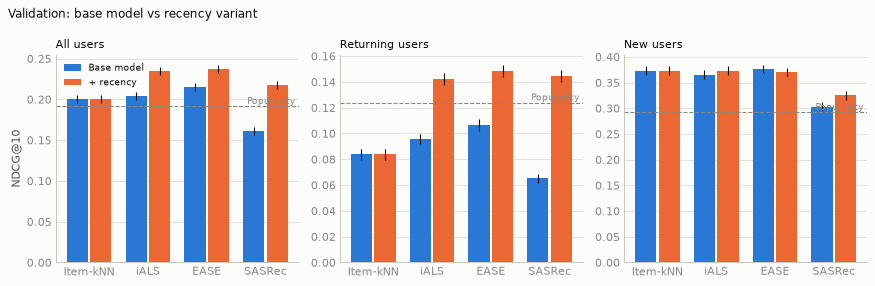

In [3]:
def paired_bars(split: str, title: str) -> None:
    bases = [name for name in MODELS if base_name(name) == name and f"{name}_recency" in MODELS]
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=False)
    x = np.arange(len(bases))
    for ax, (scope, scope_label) in zip(axes, SCOPES.items(), strict=True):
        for offset, suffix, color, series in (
            (-0.2, "", BLUE, "Base model"),
            (0.2, "_recency", ORANGE, "+ recency"),
        ):
            values = [metrics[split][f"{b}{suffix}"][scope][METRIC] for b in bases]
            means = np.array([v["mean"] for v in values])
            errors = [means - [v["ci_low"] for v in values], [v["ci_high"] for v in values] - means]
            ax.bar(
                x + offset,
                means,
                0.36,
                color=color,
                label=series,
                yerr=errors,
                ecolor=INK,
                error_kw={"lw": 1},
            )
        popularity = metrics[split]["popularity"][scope][METRIC]["mean"]
        ax.axhline(popularity, color=MUTED, lw=1, ls="--")
        ax.annotate(
            "Popularity",
            (len(bases) - 0.5, popularity),
            ha="right",
            va="bottom",
            color=MUTED,
            fontsize=8,
        )
        ax.set_xticks(x, [LABELS[b] for b in bases])
        ax.set_title(scope_label, loc="left", fontsize=10)
        ax.tick_params(length=0)
    axes[0].set_ylabel("NDCG@10")
    axes[0].legend(loc="upper left", fontsize=8)
    fig.suptitle(title, x=0.01, ha="left", fontsize=11)
    fig.tight_layout()


paired_bars("val", "Validation: base model vs recency variant")

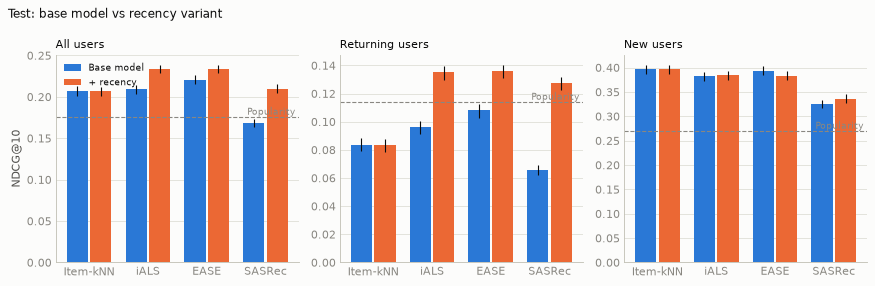

In [4]:
paired_bars("test", "Test: base model vs recency variant")

## 3. Are the differences real?

Every model is scored on the same users, so models are compared user by user (paired t-test on the
per-user NDCG@10 differences, Holm-corrected for the number of pairs). The table shows the selected
model against each of the others over all users: the mean difference, its confidence interval, and
the adjusted p-value.

In [5]:
def versus_selected(split: str) -> pd.DataFrame:
    rows = []
    for pair in comparison[split]["scopes"]["all"]["pairs"]:
        if selected not in (pair["better"], pair["worse"]):
            continue
        sign = 1 if pair["better"] == selected else -1
        other = pair["worse"] if sign == 1 else pair["better"]
        low, high = sorted((sign * pair["ci_low"], sign * pair["ci_high"]))
        rows.append(
            {
                "vs": label(other),
                "difference": sign * pair["difference"],
                "95% CI": f"[{low:.4f}, {high:.4f}]",
                "adjusted p": pair["p_adjusted"],
                "significant": pair["significant"],
            }
        )
    return pd.DataFrame(rows).set_index("vs").sort_values("difference")


print(f"{label(selected)} minus each other model, validation, all users")
versus_selected("val")

EASE + recency minus each other model, validation, all users


,difference,95% CI,adjusted p,significant
vs,,,,
iALS + recency,0.002574,"[0.0008, 0.0044]",3.065000e-02,True
SASRec + recency,0.020458,"[0.0178, 0.0231]",1.527000e-46,True
EASE,0.022821,"[0.0201, 0.0254]",6.507000e-57,True
iALS,0.033502,"[0.0305, 0.0365]",1.009000e-92,True
Item-kNN,0.037316,"[0.0340, 0.0402]",1.157000e-118,True
Item-kNN + recency,0.037456,"[0.0342, 0.0404]",1.315000e-119,True
Popularity,0.045852,"[0.0428, 0.0488]",2.943000e-188,True
SASRec,0.076584,"[0.0725, 0.0805]",1.285000e-301,True


In [6]:
print(f"{label(selected)} minus each other model, test, all users")
versus_selected("test")

EASE + recency minus each other model, test, all users


,difference,95% CI,adjusted p,significant
vs,,,,
iALS + recency,-0.000061,"[-0.0019, 0.0018]",1.000000e+00,False
EASE,0.012852,"[0.0100, 0.0157]",8.849000e-18,True
SASRec + recency,0.023753,"[0.0209, 0.0267]",4.483000e-56,True
iALS,0.024552,"[0.0213, 0.0278]",6.056000e-47,True
Item-kNN,0.026491,"[0.0233, 0.0297]",1.371000e-58,True
Item-kNN + recency,0.026603,"[0.0234, 0.0298]",1.855000e-59,True
Popularity,0.057937,"[0.0546, 0.0613]",2.796000e-240,True
SASRec,0.065127,"[0.0611, 0.0689]",1.031000e-209,True


## 4. Did validation predict test?

One point per model and group of users. Points near the diagonal mean the validation ranking carried
over to the test year; the test split is a different period with different users, so absolute values
shift.

Rank correlation, validation vs test (all users): 0.97


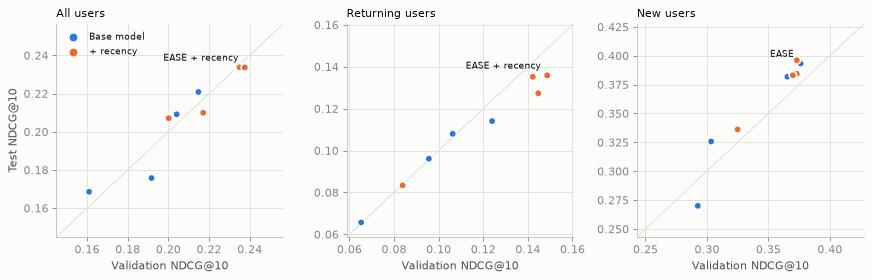

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, (scope, scope_label) in zip(axes, SCOPES.items(), strict=True):
    val = np.array([metrics["val"][name][scope][METRIC]["mean"] for name in MODELS])
    test = np.array([metrics["test"][name][scope][METRIC]["mean"] for name in MODELS])
    colors = [BLUE if base_name(name) == name else ORANGE for name in MODELS]
    low, high = min(val.min(), test.min()) * 0.9, max(val.max(), test.max()) * 1.08
    ax.plot([low, high], [low, high], color=GRID, lw=1, zorder=0)
    ax.scatter(val, test, c=colors, s=45, edgecolors="#fcfcfb", linewidths=1.5, zorder=2)
    best = int(np.argmax(val))
    ax.annotate(
        label(list(MODELS)[best]),
        (val[best], test[best]),
        xytext=(-6, 6),
        textcoords="offset points",
        ha="right",
        fontsize=8,
    )
    ax.set(xlim=(low, high), ylim=(low, high), xlabel="Validation NDCG@10", title=None)
    ax.set_title(scope_label, loc="left", fontsize=10)
    ax.grid(axis="x")
axes[0].set_ylabel("Test NDCG@10")
axes[0].scatter([], [], c=BLUE, label="Base model")
axes[0].scatter([], [], c=ORANGE, label="+ recency")
axes[0].legend(loc="upper left", fontsize=8)
fig.tight_layout()
ranks = {
    split: pd.Series({n: metrics[split][n]["all"][METRIC]["mean"] for n in MODELS}).rank()
    for split in ("val", "test")
}
print(f"Rank correlation, validation vs test (all users): {ranks['val'].corr(ranks['test']):.2f}")

## 5. Beyond accuracy

A recommender that only shows blockbusters can score well and still be a poor product. Coverage is the
share of the catalog that appears in at least one user's top 10; novelty is the mean
−log2(popularity) of the recommended movies (higher = less obvious). Returning users, test split.

,NDCG@10,Coverage@10,Novelty@10
Popularity,0.114,0.007,3.088
Item-kNN,0.084,0.033,1.986
iALS,0.096,0.079,3.105
EASE,0.108,0.079,2.795
SASRec,0.066,0.092,4.757
Item-kNN + recency,0.083,0.033,1.971
iALS + recency,0.135,0.019,2.937
EASE + recency,0.136,0.016,2.827
SASRec + recency,0.127,0.008,2.952


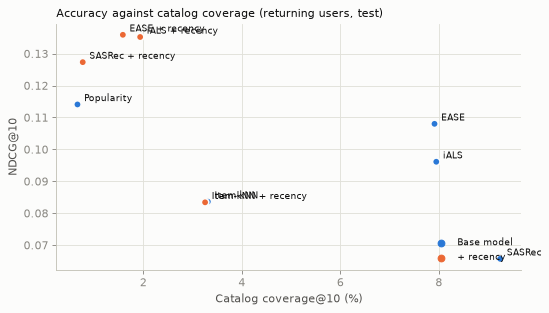

In [8]:
warm = pd.DataFrame(
    {
        "NDCG@10": {label(n): metrics["test"][n]["warm"][METRIC]["mean"] for n in MODELS},
        "Coverage@10": {label(n): metrics["test"][n]["warm"]["coverage_at_10"] for n in MODELS},
        "Novelty@10": {
            label(n): metrics["test"][n]["warm"]["novelty_at_10"]["mean"] for n in MODELS
        },
    }
)
fig, ax = plt.subplots(figsize=(7.5, 4))
colors = [BLUE if base_name(n) == n else ORANGE for n in MODELS]
ax.scatter(
    warm["Coverage@10"] * 100,
    warm["NDCG@10"],
    c=colors,
    s=45,
    edgecolors="#fcfcfb",
    linewidths=1.5,
    zorder=2,
)
for name, row in warm.iterrows():
    ax.annotate(
        name,
        (row["Coverage@10"] * 100, row["NDCG@10"]),
        xytext=(6, 3),
        textcoords="offset points",
        fontsize=8,
    )
ax.set(xlabel="Catalog coverage@10 (%)", ylabel="NDCG@10")
ax.set_title("Accuracy against catalog coverage (returning users, test)", loc="left", fontsize=10)
ax.scatter([], [], c=BLUE, label="Base model")
ax.scatter([], [], c=ORANGE, label="+ recency")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="x")
warm.round(3)

## 6. How far can EASE be pruned?

The full EASE matrix is 1.5 GB. The `ease_pruning` stage fits it once in memory and scores validation
with the full matrix and with only the strongest weights per movie.

recommended keep_per_item: 500 (params.yaml: 500)


,all,keep_per_item,onboarding,relative_drop,warm
size_mb,,,,,
1543.2,0.214792,NaN,0.376677,0.000000,0.106012
314.3,0.214702,2000.0,0.376699,0.000419,0.105847
157.1,0.214613,1000.0,0.376730,0.000833,0.105677
78.6,0.214758,500.0,0.376200,0.000158,0.106275
31.4,0.213953,200.0,0.376080,0.003906,0.105009
15.7,0.212797,100.0,0.375678,0.009288,0.103348


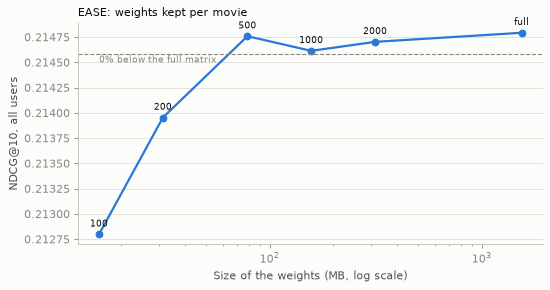

In [9]:
pruning = read("ease_pruning")
curve = pd.DataFrame(pruning["variants"]).set_index("size_mb")
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(curve.index, curve["all"], color=BLUE, lw=2, marker="o", ms=6)
ax.set_xscale("log")
ax.axhline(curve["all"].iloc[0] * (1 - pruning["max_relative_drop"]), color=MUTED, lw=1, ls="--")
ax.annotate(
    f"{pruning['max_relative_drop']:.0%} below the full matrix",
    (curve.index.min(), curve["all"].iloc[0] * (1 - pruning["max_relative_drop"])),
    va="top",
    color=MUTED,
    fontsize=8,
)
for size, row in curve.iterrows():
    text = "full" if pd.isna(row["keep_per_item"]) else f"{int(row['keep_per_item'])}"
    ax.annotate(
        text, (size, row["all"]), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8
    )
ax.set(xlabel="Size of the weights (MB, log scale)", ylabel="NDCG@10, all users")
ax.set_title("EASE: weights kept per movie", loc="left", fontsize=10)
in_params = params["models"]["ease"]["keep_per_item"]
print(
    f"recommended keep_per_item: {pruning['recommended_keep_per_item']} (params.yaml: {in_params})"
)
curve

## 7. The decision

In [10]:
lead = selection["lead_over_runner_up"]
winner = next(c for c in selection["candidates"] if c["model"] == selected)
print(
    f"Selected: {label(selected)} ({winner['model_size_mb']} MB, "
    f"budget {selection['max_model_size_mb']} MB)\n"
    f"Validation NDCG@10, all users: {winner['all']:.4f}\n"
    f"Lead over {label(selection['runner_up'])}: {lead['difference']:.4f} "
    f"[{lead['ci_low']:.4f}, {lead['ci_high']:.4f}], adjusted p = {lead['p_adjusted']}, "
    f"{'significant' if lead['significant'] else 'not significant'}\n"
    f"Test NDCG@10, all users: {metrics['test'][selected]['all'][METRIC]['mean']:.4f}"
)

Selected: EASE + recency (76.9 MB, budget 150 MB)
Validation NDCG@10, all users: 0.2376
Lead over iALS + recency: 0.0026 [0.0008, 0.0044], adjusted p = 0.03065, significant
Test NDCG@10, all users: 0.2337
